In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D , MaxPooling2D, BatchNormalization , Dropout

In [21]:
import os
print(os.path.exists("CatDogClassification/train/"))

True


In [22]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory = "CatDogClassification/train/",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)


Found 557 files belonging to 2 classes.


In [23]:
test_dataset = keras.utils.image_dataset_from_directory(
    directory = "CatDogClassification/test/",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256 , 256)
)

Found 140 files belonging to 2 classes.


In [24]:
# Normalize - converting 0 to 255 px values to (0 to 1)

def process(image , label):
    image = tf.cast(image / 255. , tf.float32)
    return image , label

train_ds = train_dataset.map(process)
test_ds = test_dataset.map(process)

In [25]:
print(train_ds)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [26]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten());

model.add(Dense(128 , activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64 , activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(1 , activation = 'sigmoid'))

e:\python\Deep Learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics = ['accuracy'])


In [29]:
history = model.fit(train_ds , epochs = 10 , validation_data=test_ds)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5260 - loss: 6.3547 - val_accuracy: 0.5000 - val_loss: 1.2724
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5691 - loss: 3.5307 - val_accuracy: 0.5071 - val_loss: 1.9135
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6463 - loss: 3.0750 - val_accuracy: 0.5000 - val_loss: 8.5610
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6715 - loss: 2.6481 - val_accuracy: 0.5000 - val_loss: 9.9940
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7666 - loss: 1.6385 - val_accuracy: 0.5071 - val_loss: 2.9595
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7846 - loss: 1.5176 - val_accuracy: 0.5000 - val_loss: 8.2973
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7828 - loss: 1.3063 - val_accuracy: 0.5000 - val_loss: 11.6855
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8241 - loss: 0.9834 - val_accuracy: 0.4929 - val_loss

In [30]:
import matplotlib.pyplot as plt

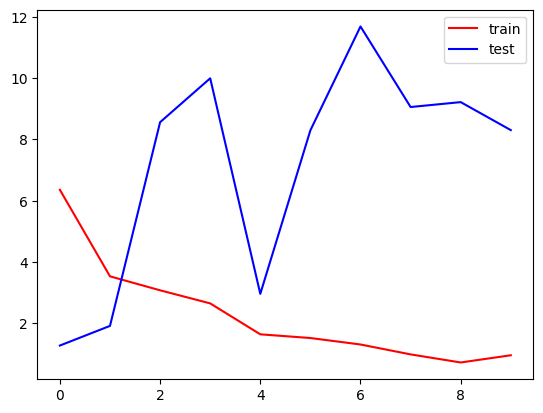

In [31]:
plt.plot(history.history['loss'] , color = 'red' , label = 'train')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'test')
plt.legend()
plt.show()

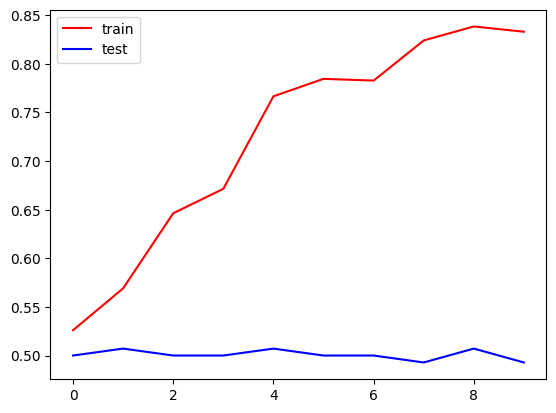

In [32]:
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'test')
plt.legend()
plt.show()